# Лабораторная работа № 1.2
## Нормальное распределение

**Выполнили:**

- Левченков Артемий Викторович;
- Бикбулатова Динара Фануровна;
- Ладыгин Максим Александрович.

**Группа:** БИВТ-24-АЭ-3

Исходные данные - дискретный ряд распределения возраста людей, совершивших преступления в Москве в 2021 году.

Цель работы: вычислить асимметрию и эксцесс, проверить правило трёх сигм и построить статистическую функцию распределения по накопленным частотам.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_table("/Users/blx000/PycharmProjects/matstat/data/moscow.txt", header=None)[0]
N = len(data)

print("Количество наблюдений:", N)
print("Минимальный возраст:", data.min())
print("Максимальный возраст:", data.max())

Количество наблюдений: 32423
Минимальный возраст: 14
Максимальный возраст: 73


### 1. Асимметрия и эксцесс

Для дискретного ряда эмпирический центральный момент порядка $k$ равен

$$\mu_k = \frac{\sum (x_i-\bar{x})^k n_i}{N}. $$

Асимметрия характеризует направление и силу отклонения распределения от симметричного вида:

$$A_s = \frac{\mu_3}{\sigma^3}. $$

Эксцесс показывает, насколько вершина распределения острее или положе вершины нормального распределения:

$$E_k = \frac{\mu_4}{\sigma^4}-3. $$

Для нормального распределения обе характеристики равны нулю.

In [2]:
discrete = data.value_counts().sort_index().rename_axis("x").reset_index(name="n")
discrete["w"] = discrete["n"] / N

print("Дискретный ряд")
display(discrete)

Дискретный ряд


,x,n,w
0,14,49,0.001511
1,15,53,0.001635
2,16,236,0.007279
3,17,126,0.003886
4,18,806,0.024859
5,19,971,0.029948
6,20,910,0.028066
7,21,716,0.022083
8,22,944,0.029115
9,23,1071,0.033032


In [3]:
def mean_value(x, n):
    return sum(x * n) / sum(n)


def dispersion(x, n, mean):
    return sum((x - mean) ** 2 * n) / sum(n)


def standard_deviation(D): #среднее кв отклонение
    return D ** 0.5


def asymmetry(x, n, mean, sigma):
    mu_3 = sum((x - mean) ** 3 * n) / sum(n)
    return mu_3 / sigma ** 3


def excess(x, n, mean, sigma):
    mu_4 = sum((x - mean) ** 4 * n) / sum(n)
    return mu_4 / sigma ** 4 - 3

In [4]:
x = discrete["x"]
n = discrete["n"]

mean = mean_value(x, n)
D = dispersion(x, n, mean)
sigma = standard_deviation(D)
A_s = asymmetry(x, n, mean, sigma)
E_k = excess(x, n, mean, sigma)

print(f"Средний возраст: {mean:.4f}")
print(f"Дисперсия: {D:.4f}")
print(f"Среднее квадратическое отклонение: {sigma:.4f}")
print(f"Асимметрия: {A_s:.4f}")
print(f"Эксцесс: {E_k:.4f}")

Средний возраст: 35.3730
Дисперсия: 144.9170
Среднее квадратическое отклонение: 12.0381
Асимметрия: 0.6225
Эксцесс: -0.0602


**Анализ результата.** Асимметрия положительна ($A_s \approx 0{,}623$), поэтому распределение имеет умеренный правый хвост: встречаются относительно большие значения возраста. Эксцесс близок к нулю ($E_k \approx -0{,}060$), следовательно, по остроте вершины распределение близко к нормальному, но немного более плоское. Из-за ненулевой асимметрии распределение нельзя считать идеально нормальным.

### 2. Проверка правила трёх сигм

Для нормального распределения около 68,3% наблюдений лежат в интервале $\bar{x} \pm \sigma$, 95,4% - в интервале $\bar{x} \pm 2\sigma$ и 99,7% - в интервале $\bar{x} \pm 3\sigma$. Посчитаем фактические доли.

In [5]:
def sigma_rule(data, mean, sigma):
    """Возвращает интервалы и доли наблюдений для 1, 2 и 3 сигм."""
    theoretical = {1: 68.3, 2: 95.4, 3: 99.7}
    rows = []

    for k in range(1, 4):
        left = mean - k * sigma
        right = mean + k * sigma
        count = ((data >= left) & (data <= right)).sum()
        actual = count / len(data) * 100
        rows.append({
            "k": k,
            "Левая граница": left,
            "Правая граница": right,
            "Количество": count,
            "Фактическая доля, %": actual,
            "Теоретическая доля, %": theoretical[k],
            "Отклонение, п.п.": actual - theoretical[k],
        })

    return pd.DataFrame(rows)


sigma_table = sigma_rule(data, mean, sigma)
display(sigma_table.round(4))

,k,Левая граница,Правая граница,Количество,"Фактическая доля, %","Теоретическая доля, %","Отклонение, п.п."
0,1,23.3349,47.4112,21513,66.3510,68.3,-1.9490
1,2,11.2967,59.4493,30695,94.6704,95.4,-0.7296
2,3,-0.7414,71.4874,32406,99.9476,99.7,0.2476


**Вывод по правилу трёх сигм.** Фактические доли равны примерно 66,35%, 94,67% и 99,95%. Они близки к теоретическим 68,3%, 95,4% и 99,7%, поэтому правило трёх сигм выполняется приближённо. Это даёт основание считать распределение возраста приближённо нормальным. Однако правило трёх сигм является ориентиром, а не строгим критерием: заметная положительная асимметрия указывает, что соответствие нормальному распределению не является точным.

### 3. Статистическая функция распределения

Накопленная частота $S_i$ показывает, сколько наблюдений не превышает $x_i$. Накопленная относительная частота

$$F^*(x_i) = \frac{S_i}{N}$$

является значением статистической функции распределения. График строим по значениям возраста и накопленным относительным частотам.

,x,n,w,S,F
0,14,49,0.0015,49,0.0015
1,15,53,0.0016,102,0.0031
2,16,236,0.0073,338,0.0104
3,17,126,0.0039,464,0.0143
4,18,806,0.0249,1270,0.0392
5,19,971,0.0299,2241,0.0691
6,20,910,0.0281,3151,0.0972
7,21,716,0.0221,3867,0.1193
8,22,944,0.0291,4811,0.1484
9,23,1071,0.0330,5882,0.1814


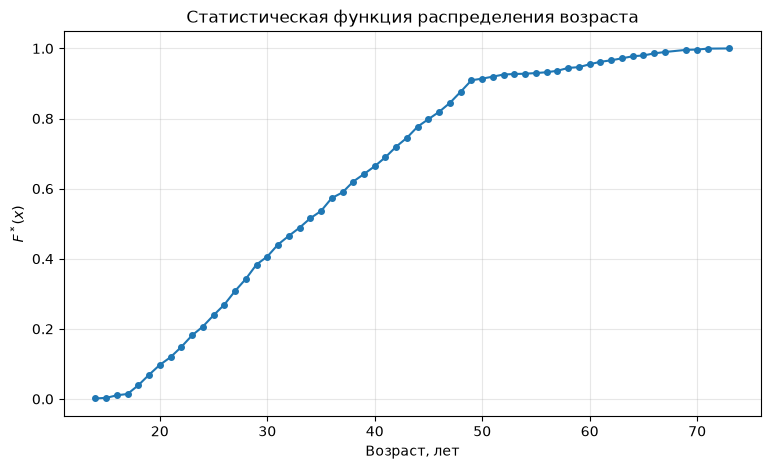

In [6]:
distribution = discrete.copy()
distribution["S"] = distribution["n"].cumsum()
distribution["F"] = distribution["S"] / N

display(distribution.round(4))

plt.figure(figsize=(9, 5))
plt.plot(distribution["x"], distribution["F"], marker="o", markersize=4)
plt.title("Статистическая функция распределения возраста")
plt.xlabel("Возраст, лет")
plt.ylabel("$F^*(x)$")
plt.grid(alpha=0.3)
plt.show()

### Итоговый вывод

Средний возраст составляет около 35,37 года, среднее квадратическое отклонение - около 12,04 года. Положительная асимметрия $A_s \approx 0{,}623$ показывает умеренное смещение распределения вправо, а эксцесс $E_k \approx -0{,}060$ говорит о близкой к нормальной остроте вершины. Фактические доли наблюдений в пределах одной, двух и трёх сигм близки к теоретическим. Поэтому распределение можно считать **приближённо нормальным по правилу трёх сигм**, но не идеально нормальным из-за правосторонней асимметрии. Статистическая функция распределения не убывает, принимает значения от 0 до 1 и в конце достигает 1, что соответствует её основным свойствам.